### SUPPORT VECTOR CLASSIFIER MODELING

**SVC** models are built.      
The parameter 'class_weight="balanced"' is used to address the class imbalance.      
The features are scaled.      
The model parameters are optimized using GridSearchCV. Scoring is based on 'recall' to try to reduce the number of **False Negatives** to zero.     
In line with this, the threshold is tuned to the absolute minimum threshold.     
Sequential feature selection reduces the **False Positives**.    
The model performance metrics and feature importances are output separately and compared with other models in a separate notebook.
Sample predictions using the model are demonstrated.


**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel

**Load dataset**

In [2]:
# Load dataset
df = pd.read_csv('cleaned_data_bcw.csv')

In [3]:
# Examine dataset
df.head().T

,0,1,2,3,4
diagnosis,1.000000,1.000000,1.000000,1.000000,1.000000
radius_mean,17.990000,20.570000,19.690000,11.420000,20.290000
texture_mean,10.380000,17.770000,21.250000,20.380000,14.340000
perimeter_mean,122.800000,132.900000,130.000000,77.580000,135.100000
area_mean,1001.000000,1326.000000,1203.000000,386.100000,1297.000000
smoothness_mean,0.118400,0.084740,0.109600,0.142500,0.100300
compactness_mean,0.277600,0.078640,0.159900,0.283900,0.132800
concavity_mean,0.300100,0.086900,0.197400,0.241400,0.198000
concave points_mean,0.147100,0.070170,0.127900,0.105200,0.104300
symmetry_mean,0.241900,0.181200,0.206900,0.259700,0.180900


In [4]:
# Check number of rows and columns
df.shape

(569, 31)

In [5]:
# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [6]:
# Verify data
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
# Define X and y then split into train and test sets
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
# Correlation check
corr = X.corr().abs()
corr

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,0.023389,0.236702,0.302418,0.293464,0.071401,0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,0.311631,0.076437,0.261477,0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,0.253691,0.051269,0.205151,0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [9]:
# Build the pipeline
# Use the parameter class_weight='balanced' to address the imbalanced dataset, scale the features
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
])
pipe.fit(X_train, y_train)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('svc',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [10]:
# Accuracy of model on train and test data
pipe_acc_train = pipe.score(X_train, y_train)
pipe_acc_test = pipe.score(X_test, y_test)

print(f'The train accuracy of the model is {pipe_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {pipe_acc_test*100:.2f}%')

The train accuracy of the model is 98.68%
The test accuracy of the model is 98.25%


In [11]:
# Define parameter grid
param_grid = {
    'svc__C': [0.01, 0.1],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ["scale", 0.01, 0.001]
}

In [12]:
# Run RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train, y_train)

print(f'The best parameters are {grid.best_params_}')
print(f'The best score is {grid.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameters are {'svc__kernel': 'linear', 'svc__gamma': 'scale', 'svc__C': 0.01}
The best score is 0.9471


In [13]:
# Accuracy of model on train and test data
best_model = grid.best_estimator_

best_model_acc_train = best_model.score(X_train, y_train)
best_model_acc_test = best_model.score(X_test, y_test)

print(f'The train accuracy of the model is {best_model_acc_train*100:.2f}%')
print(f'The test accuracy of the model is {best_model_acc_test*100:.2f}%')

The train accuracy of the model is 98.02%
The test accuracy of the model is 99.12%


In [14]:
# Evaluate the best model
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

ROC AUC: 0.998015873015873
PR AUC: 0.9970238095238095


There is only one (1) **False Negative** and there is zero **False Positive**. The False Negative is reduced to zero by tuning the threshold.

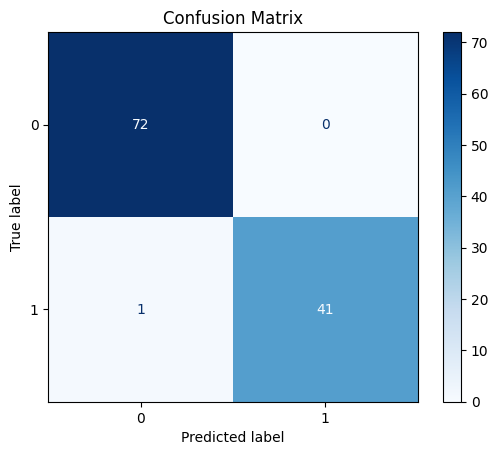

In [15]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

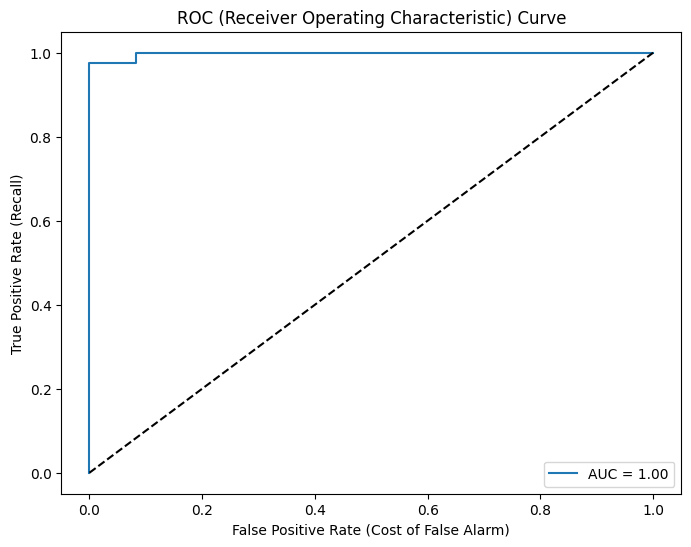

In [16]:
# Plot the ROC Curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = round(roc_auc_score(y_test, y_probs), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [17]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

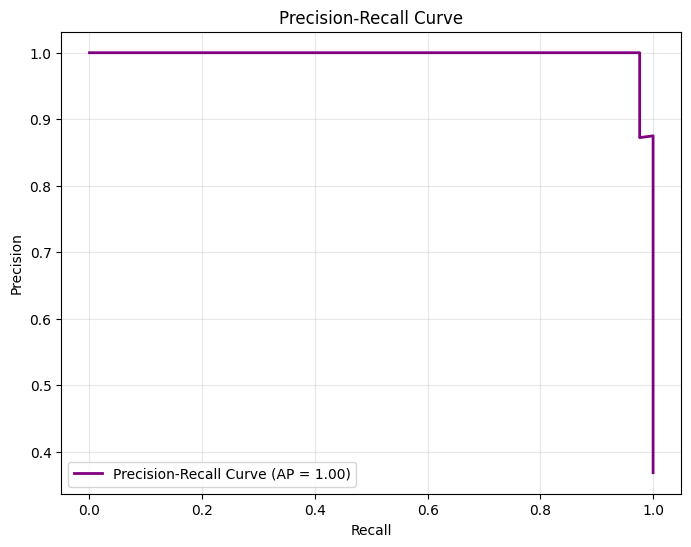

In [18]:
# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [19]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.60, 0.05)

for threshold in thresholds:
    preds = (y_probs >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.37 | Recall=1.00
Threshold=0.05 | Precision=0.79 | Recall=1.00
Threshold=0.10 | Precision=0.86 | Recall=1.00
Threshold=0.15 | Precision=0.88 | Recall=1.00
Threshold=0.20 | Precision=0.91 | Recall=0.98
Threshold=0.25 | Precision=0.91 | Recall=0.98
Threshold=0.30 | Precision=0.95 | Recall=0.98
Threshold=0.35 | Precision=0.98 | Recall=0.98
Threshold=0.40 | Precision=0.98 | Recall=0.98
Threshold=0.45 | Precision=1.00 | Recall=0.98
Threshold=0.50 | Precision=1.00 | Recall=0.98
Threshold=0.55 | Precision=1.00 | Recall=0.98


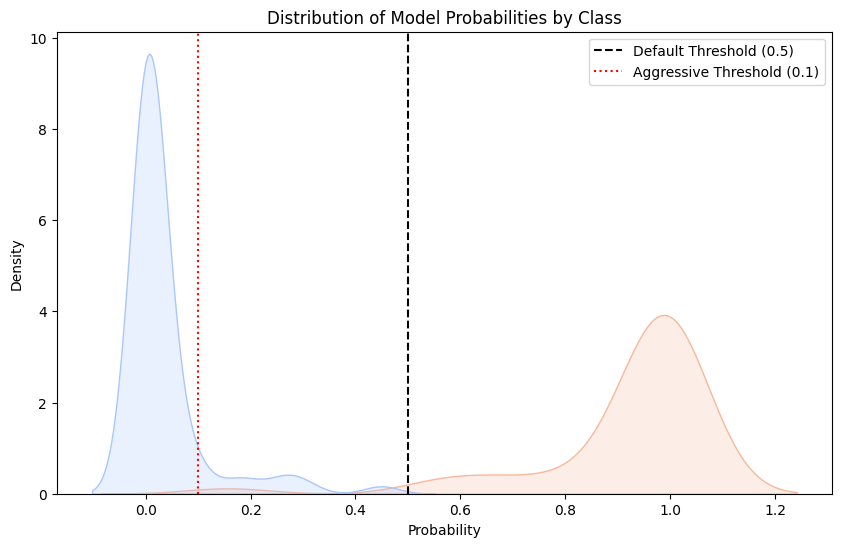

In [20]:
# Get probabilities for the positive class (Malignant)
y_probs = best_model.predict_proba(X_test)[:, 1]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({'Probability': y_probs, 'Actual': y_test})

plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df, x='Probability', hue='Actual', fill=True, common_norm=False, palette='coolwarm')

# Draw the current threshold (0.5)
plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')

# Draw a proposed aggressive threshold (e.g., 0.1)
plt.axvline(x=0.1, color='red', linestyle=':', label='Aggressive Threshold (0.1)')

plt.title('Distribution of Model Probabilities by Class')
plt.legend()
plt.show()

In [21]:
# Find the absolute minimum probability assigned to any malignant case
absolute_min_threshold = y_probs[y_test == 1].min()

print(f"Threshold for Zero False Negatives: {absolute_min_threshold:.4f}")

Threshold for Zero False Negatives: 0.1560


In [22]:
# Create final predictions
y_pred_final = (y_probs >= absolute_min_threshold).astype(int)

In [23]:
# Generate classification

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        72
           1       0.88      1.00      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.96      0.94       114
weighted avg       0.95      0.95      0.95       114



The **False Negatives** are reduced to zero, however, there are now six (6) **False Positives**.

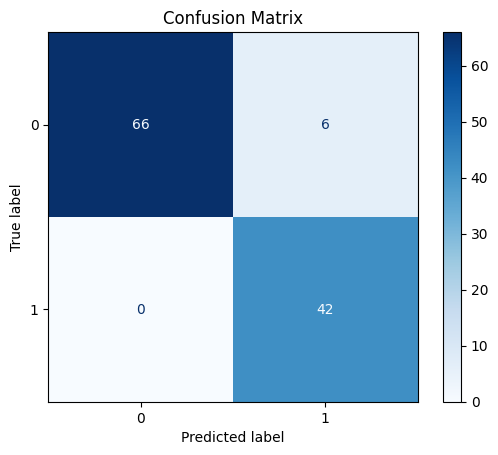

In [24]:
# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

**Feature Importance**

In [25]:
# Use permutation importance
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

In [26]:
# Interpret the results
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': result.importances_mean
}).sort_values(by='importance_mean', ascending=False)

# Reset index
feature_importance_df = feature_importance_df.reset_index(drop=True)
feature_importance_df.index = feature_importance_df.index + 1
feature_importance_df.index.name = "Rank"

feature_importance_df.head(10)

,feature,importance_mean
Rank,,
1,texture_worst,0.071429
2,concave points_worst,0.057143
3,texture_mean,0.039286
4,perimeter_worst,0.039286
5,radius_worst,0.039286
6,fractal_dimension_mean,0.038095
7,radius_mean,0.034524
8,concavity_worst,0.034524
9,perimeter_mean,0.033333


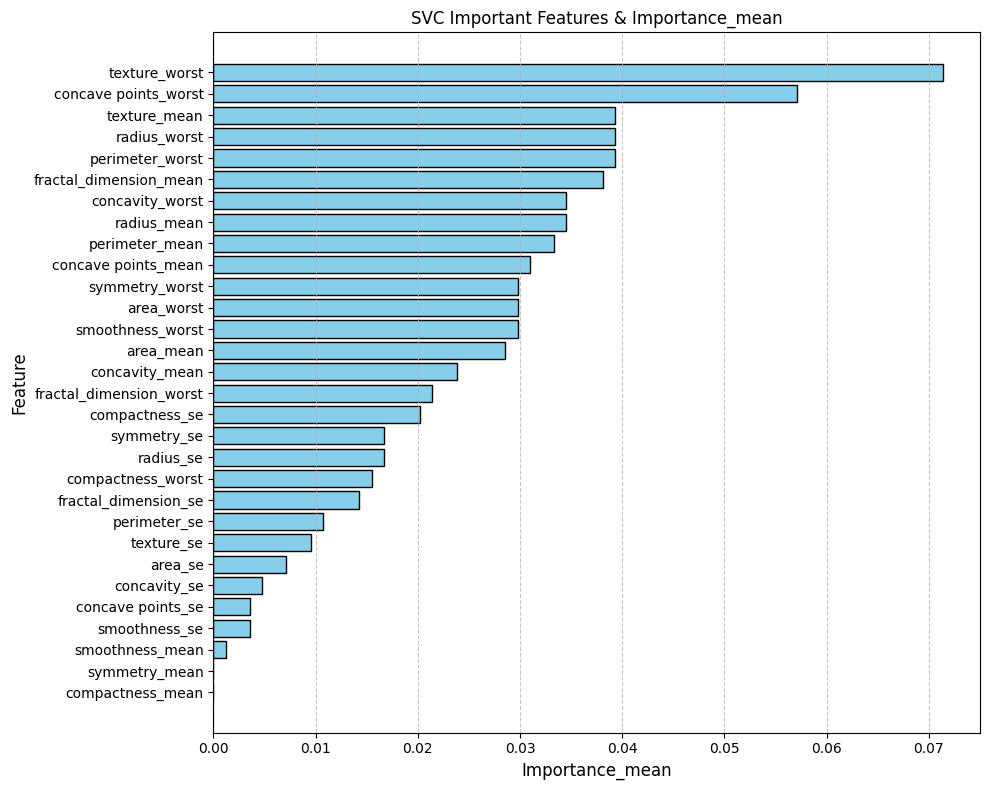

In [27]:
# Plot the feature and importance
feature_importance_df = feature_importance_df.sort_values(by='importance_mean')
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in feature_importance_df['importance_mean']]
plt.barh(feature_importance_df['feature'], feature_importance_df['importance_mean'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('SVC Important Features & Importance_mean')
plt.xlabel('Importance_mean', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Sequential Feature Selection**     

Feature selection reduces noise and improves the interpretation of feature importance.
    
Feature selection is about removing noise, improving interpretability, improving logistic regression stability, and slightly reducing overfitting.

In [28]:
# Define the classifier
model = SVC(class_weight='balanced', probability=True, random_state=42)

In [29]:
# Instantiate Sequential Feature Selector
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select="auto",
    direction="forward",
    scoring="recall",
    cv=3
)

In [30]:
# Build pipeline including sequential feature selection
pipe1 = Pipeline([
    ("scale", StandardScaler()),
    ("sfs", sfs),
    ("svc", model)
])
pipe1.fit(X_train, y_train)
pipe1

Pipeline(steps=[('scale', StandardScaler()),
                ('sfs',
                 SequentialFeatureSelector(cv=3,
                                           estimator=SVC(class_weight='balanced',
                                                         probability=True,
                                                         random_state=42),
                                           scoring='recall')),
                ('svc',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [31]:
# Define parameter grid
param_grid = {
    'svc__C': [0.01, 0.1],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ["scale", 0.01, 0.001]
}

In [32]:
# Run RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid1 = RandomizedSearchCV(
    estimator=pipe1,
    param_distributions=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)
grid1.fit(X_train, y_train)

print(f'The best parameters are {grid1.best_params_}')
print(f'The best score is {grid1.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best parameters are {'svc__kernel': 'linear', 'svc__gamma': 0.001, 'svc__C': 0.1}
The best score is 0.9412


In [33]:
# Get the best model from the grid search and selected features
best_model1 = grid1.best_estimator_
feature_names = X_train.columns
mask = best_model1.named_steps["sfs"].get_support()
selected_features = feature_names[mask]

print(selected_features, '\n')
print(f'There are {len(selected_features)} selected features.')

Index(['radius_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
       'compactness_mean', 'concavity_mean', 'concave points_mean',
       'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se',
       'perimeter_se', 'area_se', 'radius_worst', 'texture_worst'],
      dtype='object') 

There are 15 selected features.


In [34]:
# Generate classification report
y_pred1 = best_model1.predict(X_test)

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        72
           1       0.95      0.90      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



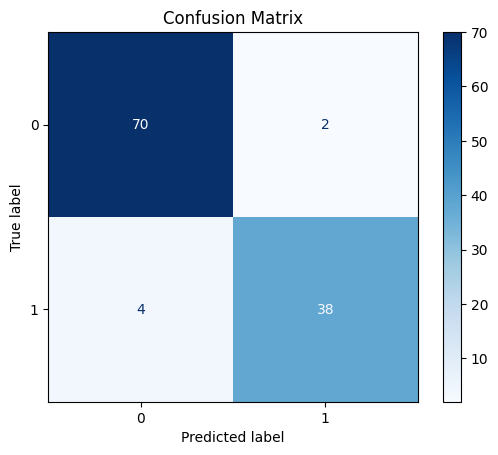

In [35]:
# Display confusion matrix
conf_matrix1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(conf_matrix1, display_labels=[0, 1])
disp1.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

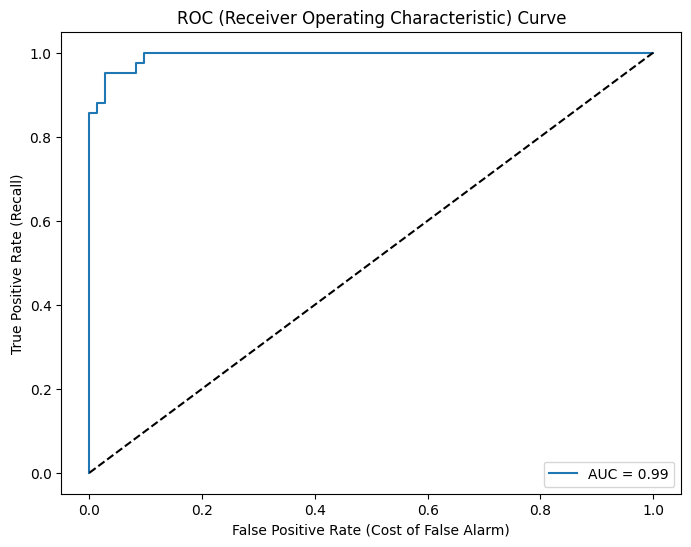

In [36]:
# Plot the ROC Curve
y_probs1 = best_model1.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs1)
auc = round(roc_auc_score(y_test, y_probs1), 3)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_probs1):.2f}')
plt.plot([0,1], [0,1], 'k--') # diagonal line representing random guessing
plt.title('ROC (Receiver Operating Characteristic) Curve')
plt.xlabel('False Positive Rate (Cost of False Alarm)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

In [37]:
# Calculate precision and recall for all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs1)
avg_precision = average_precision_score(y_test, y_probs1)

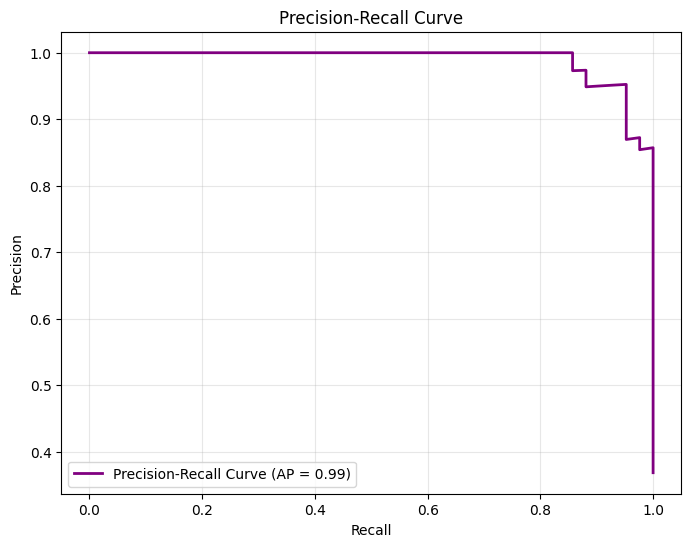

In [38]:
# Plot the curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {avg_precision:.2f})', color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(alpha=0.3)
plt.legend(loc='best')
plt.show()

In [39]:
# Evaluate precision and recall at different thresholds
thresholds = np.arange(0, 0.60, 0.05)

for threshold in thresholds:
    preds = (y_probs1 >= threshold).astype(int)
    print(f'Threshold={threshold:.2f} | Precision={precision_score(y_test, preds):.2f} | Recall={recall_score(y_test, preds):.2f}')

Threshold=0.00 | Precision=0.37 | Recall=1.00
Threshold=0.05 | Precision=0.81 | Recall=1.00
Threshold=0.10 | Precision=0.87 | Recall=0.98
Threshold=0.15 | Precision=0.87 | Recall=0.95
Threshold=0.20 | Precision=0.91 | Recall=0.95
Threshold=0.25 | Precision=0.91 | Recall=0.95
Threshold=0.30 | Precision=0.93 | Recall=0.95
Threshold=0.35 | Precision=0.95 | Recall=0.93
Threshold=0.40 | Precision=0.95 | Recall=0.93
Threshold=0.45 | Precision=0.97 | Recall=0.88
Threshold=0.50 | Precision=0.97 | Recall=0.86
Threshold=0.55 | Precision=0.97 | Recall=0.86


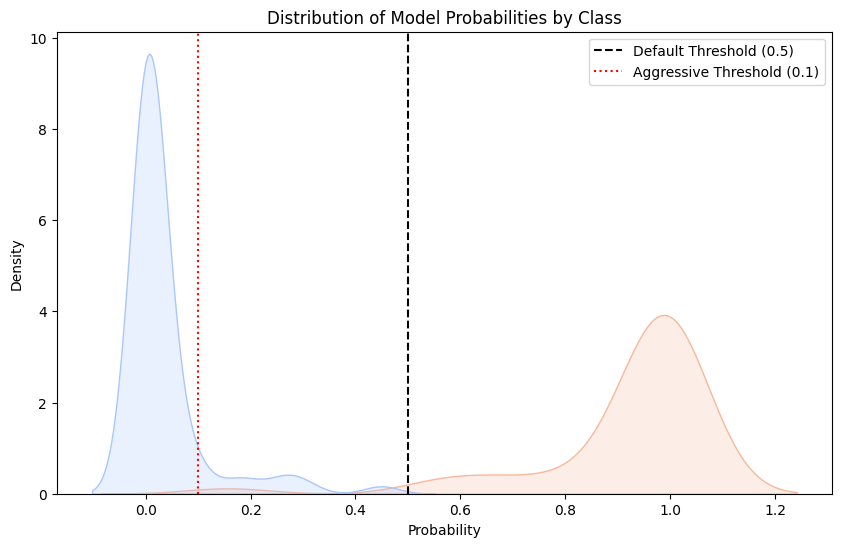

In [40]:
# Get probabilities for the positive class (Malignant)
y_probs1 = best_model.predict_proba(X_test)[:, 1]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({'Probability': y_probs1, 'Actual': y_test})

plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df, x='Probability', hue='Actual', fill=True, common_norm=False, palette='coolwarm')

# Draw the current threshold (0.5)
plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')

# Draw a proposed aggressive threshold (e.g., 0.1)
plt.axvline(x=0.1, color='red', linestyle=':', label='Aggressive Threshold (0.1)')

plt.title('Distribution of Model Probabilities by Class')
plt.legend()
plt.show()

In [41]:
# Find the absolute minimum probability assigned to any malignant case
absolute_min_threshold = y_probs1[y_test == 1].min()

print(f"Threshold for Zero False Negatives: {absolute_min_threshold:.4f}")

Threshold for Zero False Negatives: 0.1560


In [42]:
# Create final predictions
y_pred_final1 = (y_probs >= absolute_min_threshold).astype(int)

In [43]:
# Generate classification report

print(classification_report(y_test, y_pred_final1))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        72
           1       0.88      1.00      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.96      0.94       114
weighted avg       0.95      0.95      0.95       114



**False positives** stayed the same at six (6) after feature reduction.

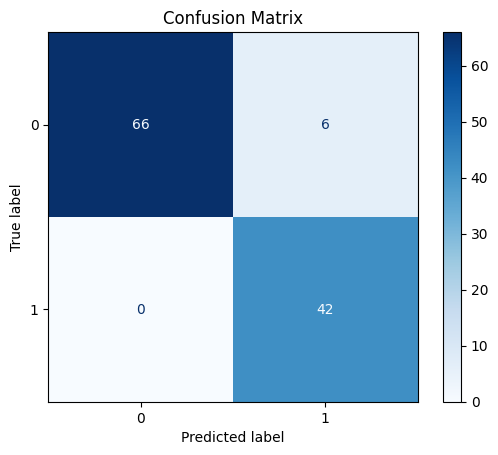

In [44]:
# Display confusion matrix
conf_matrix2 = confusion_matrix(y_test, y_pred_final1)
disp2 = ConfusionMatrixDisplay(conf_matrix2, display_labels=[0, 1])
disp2.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [45]:
# Values for false positive (fp), false negative (fn), true positive (tp) and true negative (tn)
fp = conf_matrix2[0][1]
fn = conf_matrix2[1][0]
tp = conf_matrix2[1][1]
tn = conf_matrix2[0][0]

print(f' fp: {fp} \n fn: {fn} \n tp: {tp} \n tn_L5: {tn}')

 fp: 6 
 fn: 0 
 tp: 42 
 tn_L5: 66


In [46]:
# Calculations for accuracy, precision, recall
accuracy = (tp + tn)/len(y_test)
precision = tp/(tp + fp)
recall = tp/(tp + fn)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'-'*15)

Accuracy: 0.95
Precision: 0.88
Recall: 1.00
---------------


In [47]:
# Build a dataframe summarizing the model properties
svc_metrics_df = pd.DataFrame({
    'Model': ['SVC'],
    'ROC_AUC': [auc],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'False_Negatives': [fn],
    'False_Positives': [fp],
})
svc_metrics_df

,Model,ROC_AUC,Accuracy,Precision,Recall,False_Negatives,False_Positives
0,SVC,0.993,0.947368,0.875,1.0,0,6


**Feature Importance**

The important features are the following:    
**perimeter_worst**     
**texture_worst**     
**smoothness_worst**    
**fractal_dimension_worst**         
**compactness_mean**       
**radius_se**     

In [48]:
# Calculate importance
result = permutation_importance(
    best_model1, X_test, y_test, n_repeats=10, random_state=42, scoring='recall'
)

# Organize into a dataFrame
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

# Filter for selected features
selected_features = X.columns[best_model1.named_steps["sfs"].get_support()]
final_importance = importance_df[importance_df['feature'].isin(selected_features)]

feature_importance_df = final_importance.iloc[:,:2]

print(f'The selected features and their importances are: \n \n {feature_importance_df} \n')
print(f'There are {len(feature_importance_df)} importances_mean.')

The selected features and their importances are: 
 
                    feature  importance_mean
21           texture_worst         0.083333
6           concavity_mean         0.026190
7      concave points_mean         0.021429
3                area_mean         0.016667
0              radius_mean         0.016667
9   fractal_dimension_mean         0.016667
20            radius_worst         0.016667
2           perimeter_mean         0.016667
4          smoothness_mean         0.014286
11              texture_se         0.009524
12            perimeter_se         0.004762
5         compactness_mean         0.004762
8            symmetry_mean         0.004762
10               radius_se         0.000000
13                 area_se        -0.002381 

There are 15 importances_mean.


In [49]:
# Reset index
feature_importance_df = feature_importance_df.reset_index(drop=True)
feature_importance_df.index = feature_importance_df.index + 1
feature_importance_df.index.name = "Rank"

feature_importance_df.head(10)

,feature,importance_mean
Rank,,
1,texture_worst,0.083333
2,concavity_mean,0.026190
3,concave points_mean,0.021429
4,area_mean,0.016667
5,radius_mean,0.016667
6,fractal_dimension_mean,0.016667
7,radius_worst,0.016667
8,perimeter_mean,0.016667
9,smoothness_mean,0.014286


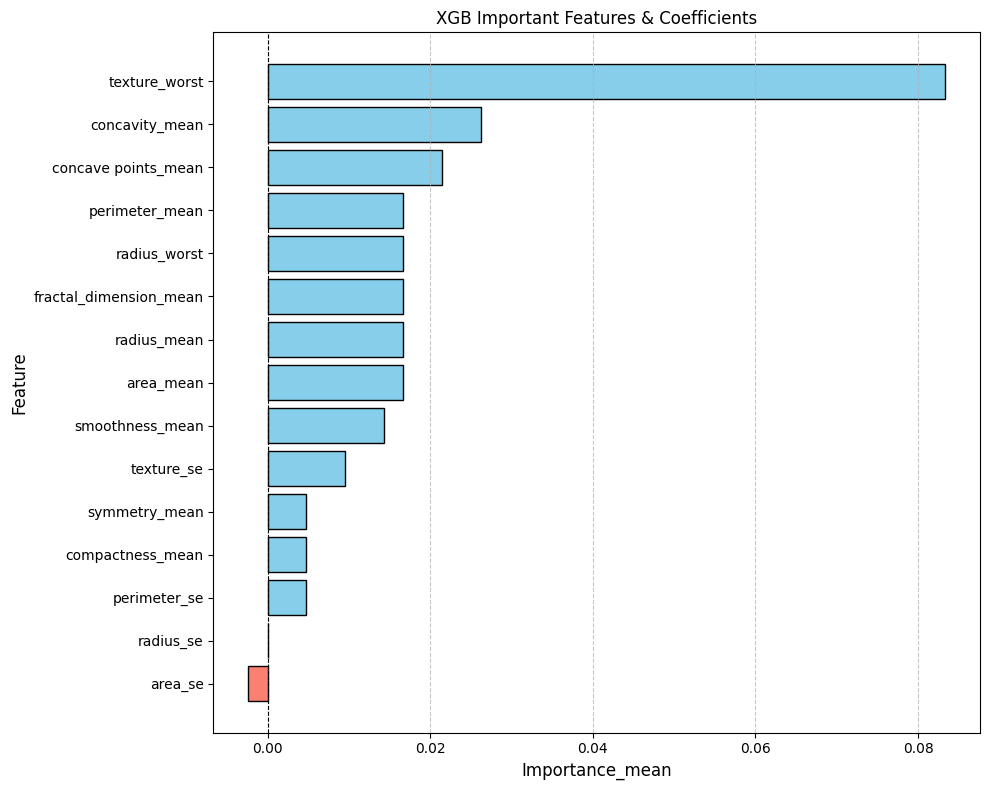

In [50]:
# Plot the feature and importance
feature_importance_df = feature_importance_df.sort_values(by='importance_mean')
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in feature_importance_df['importance_mean']]
plt.barh(feature_importance_df['feature'], feature_importance_df['importance_mean'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('XGB Important Features & Coefficients')
plt.xlabel('Importance_mean', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
# Output the Logistic Regression model performance metrics
svc_metrics_df.to_csv("svc_metrics.csv", index=False)

In [52]:
# Output the feature importance
feature_importance_df.to_csv("svc_features.csv", index=False)

**Sample Predictions**

In [53]:
# List indices of malignant cases
malignant_idx = y_test[y_test == 1].index

print(malignant_idx)

Index([250,  99,  39, 479, 280,  73, 218,  34,  86, 100,  64, 468,  70, 118,
       451,  22, 385,   7, 196, 219,  83, 207, 563,  14, 321, 198,   5, 162,
         4,  94, 277, 177, 433, 533, 190, 487, 393, 329, 282, 503, 205,  75],
      dtype='int64')


**Sample 1**

In [54]:
# Obtain a sample from the test data
df_test1 = X_test.loc[39]

print(df_test1, '\n')
print(f'Actual diagnosis is {y_test.loc[39]}')

radius_mean                 13.480000
texture_mean                20.820000
perimeter_mean              88.400000
area_mean                  559.200000
smoothness_mean              0.101600
compactness_mean             0.125500
concavity_mean               0.106300
concave points_mean          0.054390
symmetry_mean                0.172000
fractal_dimension_mean       0.064190
radius_se                    0.213000
texture_se                   0.591400
perimeter_se                 1.545000
area_se                     18.520000
smoothness_se                0.005367
compactness_se               0.022390
concavity_se                 0.030490
concave points_se            0.012620
symmetry_se                  0.013770
fractal_dimension_se         0.003187
radius_worst                15.530000
texture_worst               26.020000
perimeter_worst            107.300000
area_worst                 740.400000
smoothness_worst             0.161000
compactness_worst            0.422500
concavity_wo

In [55]:
# Transfer the data to a dictionary
sample1 = {    "radius_mean": 13.480000,    "texture_mean": 20.820000,    "perimeter_mean": 88.400000,    "area_mean": 559.200000,    "smoothness_mean": 0.101600,    "compactness_mean": 0.125500,    "concavity_mean": 0.106300,    "concave points_mean": 0.054390,    "symmetry_mean": 0.172000,    "fractal_dimension_mean": 0.064190,    "radius_se": 0.213000,    "texture_se": 0.591400,    "perimeter_se": 1.545000,    "area_se": 18.520000,    "smoothness_se": 0.005367,    "compactness_se": 0.022390,    "concavity_se": 0.030490,    "concave points_se": 0.012620,    "symmetry_se": 0.013770,    "fractal_dimension_se": 0.003187,    "radius_worst": 15.530000,    "texture_worst": 26.020000,    "perimeter_worst": 107.300000,    "area_worst": 740.400000,    "smoothness_worst": 0.161000,    "compactness_worst": 0.422500,    "concavity_worst": 0.503000,    "concave points_worst": 0.225800,    "symmetry_worst": 0.280700,    "fractal_dimension_worst": 0.107100}

In [56]:
# Calculate positive probability of the sample and provide diagnosis of the sample
probability1 = best_model1.predict_proba(pd.DataFrame([sample1]))[:, 1][0]

if probability1 >= absolute_min_threshold:
    print(f'The predicted diagnosis is 1 \n')
else:
    print(f'The predicted diagnosis is 0 \n')

print(f'The predicted positive probability is {probability1:.2f}')

The predicted diagnosis is 1 

The predicted positive probability is 0.44


In [57]:
# Obtain a sample from the test data
df_test2 = X_test.loc[198]

print(df_test2, '\n')
print(f'Actual diagnosis is {y_test.loc[198]}')

radius_mean                  19.180000
texture_mean                 22.490000
perimeter_mean              127.500000
area_mean                  1148.000000
smoothness_mean               0.085230
compactness_mean              0.142800
concavity_mean                0.111400
concave points_mean           0.067720
symmetry_mean                 0.176700
fractal_dimension_mean        0.055290
radius_se                     0.435700
texture_se                    1.073000
perimeter_se                  3.833000
area_se                      54.220000
smoothness_se                 0.005524
compactness_se                0.036980
concavity_se                  0.027060
concave points_se             0.012210
symmetry_se                   0.014150
fractal_dimension_se          0.003397
radius_worst                 23.360000
texture_worst                32.060000
perimeter_worst             166.400000
area_worst                 1688.000000
smoothness_worst              0.132200
compactness_worst        

In [58]:
# Transfer the data to a dictionary
sample2 = {
    "radius_mean": 19.180000,
    "texture_mean": 22.490000,
    "perimeter_mean": 127.500000,
    "area_mean": 1148.000000,
    "smoothness_mean": 0.085230,
    "compactness_mean": 0.142800,
    "concavity_mean": 0.111400,
    "concave points_mean": 0.067720,
    "symmetry_mean": 0.176700,
    "fractal_dimension_mean": 0.055290,
    "radius_se": 0.435700,
    "texture_se": 1.073000,
    "perimeter_se": 3.833000,
    "area_se": 54.220000,
    "smoothness_se": 0.005524,
    "compactness_se": 0.036980,
    "concavity_se": 0.027060,
    "concave points_se": 0.012210,
    "symmetry_se": 0.014150,
    "fractal_dimension_se": 0.003397,
    "radius_worst": 23.360000,
    "texture_worst": 32.060000,
    "perimeter_worst": 166.400000,
    "area_worst": 1688.000000,
    "smoothness_worst": 0.132200,
    "compactness_worst": 0.560100,
    "concavity_worst": 0.386500,
    "concave points_worst": 0.170800,
    "symmetry_worst": 0.319300,
    "fractal_dimension_worst": 0.092210
}

In [59]:
# Calculate positive probability of the sample and provide diagnosis of the sample
probability2 = best_model1.predict_proba(pd.DataFrame([sample2]))[:, 1][0]

if probability2 >= absolute_min_threshold:
    print(f'The predicted diagnosis is 1 \n')
else:
    print(f'The predicted diagnosis is 0 \n')

print(f'The predicted positive probability is {probability2:.2f}')

The predicted diagnosis is 1 

The predicted positive probability is 1.00


In [60]:
# Obtain a sample from the test data
df_test3 = X_test.loc[250]

print(df_test3, '\n')
print(f'Actual diagnosis is {y_test.loc[250]}')

radius_mean                  20.940000
texture_mean                 23.560000
perimeter_mean              138.900000
area_mean                  1364.000000
smoothness_mean               0.100700
compactness_mean              0.160600
concavity_mean                0.271200
concave points_mean           0.131000
symmetry_mean                 0.220500
fractal_dimension_mean        0.058980
radius_se                     1.004000
texture_se                    0.820800
perimeter_se                  6.372000
area_se                     137.900000
smoothness_se                 0.005283
compactness_se                0.039080
concavity_se                  0.095180
concave points_se             0.018640
symmetry_se                   0.024010
fractal_dimension_se          0.005002
radius_worst                 25.580000
texture_worst                27.000000
perimeter_worst             165.300000
area_worst                 2010.000000
smoothness_worst              0.121100
compactness_worst        

In [61]:
# Transfer the data to a dictionary
sample3 = {
    "radius_mean": 20.940000,
    "texture_mean": 23.560000,
    "perimeter_mean": 138.900000,
    "area_mean": 1364.000000,
    "smoothness_mean": 0.100700,
    "compactness_mean": 0.160600,
    "concavity_mean": 0.271200,
    "concave points_mean": 0.131000,
    "symmetry_mean": 0.220500,
    "fractal_dimension_mean": 0.058980,
    "radius_se": 1.004000,
    "texture_se": 0.820800,
    "perimeter_se": 6.372000,
    "area_se": 137.900000,
    "smoothness_se": 0.005283,
    "compactness_se": 0.039080,
    "concavity_se": 0.095180,
    "concave points_se": 0.018640,
    "symmetry_se": 0.024010,
    "fractal_dimension_se": 0.005002,
    "radius_worst": 25.580000,
    "texture_worst": 27.000000,
    "perimeter_worst": 165.300000,
    "area_worst": 2010.000000,
    "smoothness_worst": 0.121100,
    "compactness_worst": 0.317200,
    "concavity_worst": 0.699100,
    "concave points_worst": 0.210500,
    "symmetry_worst": 0.312600,
    "fractal_dimension_worst": 0.078490
}

In [62]:
# Calculate positive probability of the sample and provide diagnosis of the sample
probability3 = best_model1.predict_proba(pd.DataFrame([sample3]))[:, 1][0]

if probability3 >= absolute_min_threshold:
    print(f'The predicted diagnosis is 1 \n')
else:
    print(f'The predicted diagnosis is 0 \n')

print(f'The predicted positive probability is {probability3:.2f}')

The predicted diagnosis is 1 

The predicted positive probability is 1.00
